# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

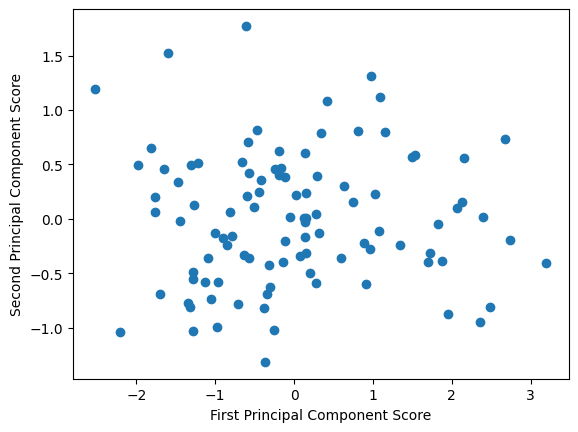

In [4]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper-left corner have low values on the first principal component and high values on the second. From the PCA loadings, the first component captures overall variation across the series, while the second reflects a contrast between series_1 and series_2 versus series_3. This suggests that these points have relatively low values of series_3 and comparatively higher values of series_1 and series_2. It is easier to interpret series_3 because it has greater variability, while series_1 and series_2 are highly correlated since series_2 was constructed as a slightly perturbed version of series_1. As a result, PCA combines their shared variation, making it difficult to distinguish their individual contributions or relative values. The plot is useful for identifying outliers and reducing dimensionality, and it highlights observations where series_3 deviates from the main trend, but it sacrifices interpretability due to the use of linear combinations of correlated variables.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [6]:
import pandas as pd

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


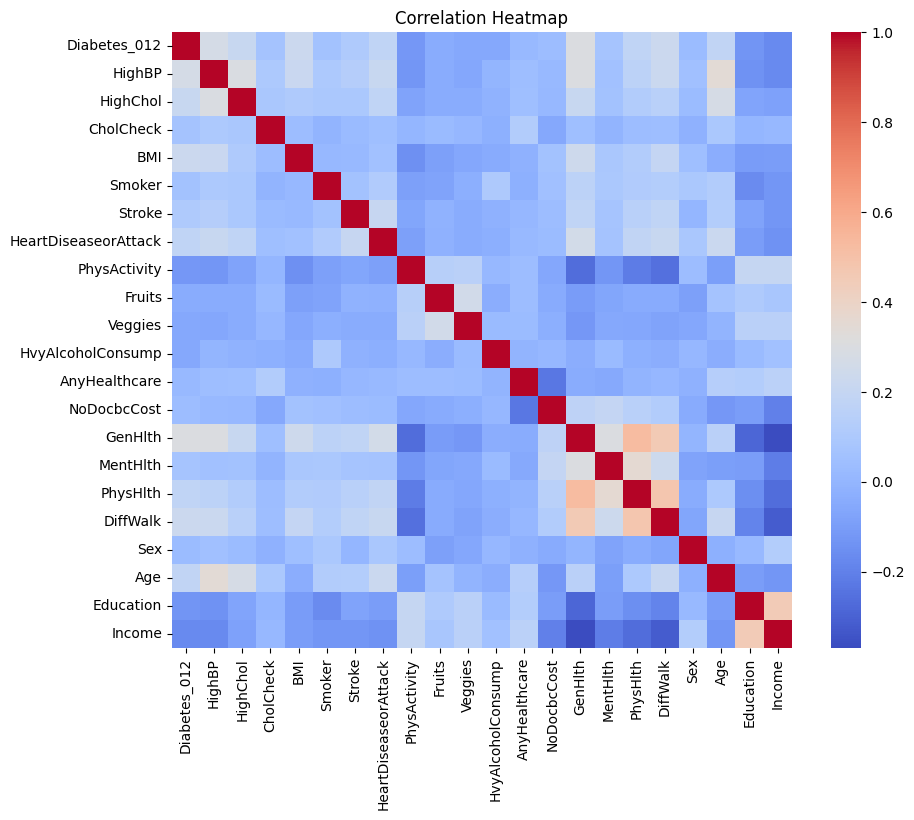

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that most features have relatively weak correlations with each other, suggesting that the dataset is not highly redundant. However, there are a few moderate relationships, particularly among general health indicators such as GenHlth, PhysHlth, and DiffWalk, which appear to be positively correlated. Additionally, factors like BMI, HighBP, and Age show some correlation with Diabetes_012, indicating they may be useful predictors. Overall, the dataset contains a mix of independent and moderately related features, which is suitable for further analysis.

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Diabetes_012"])  # target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

print(pca.explained_variance_ratio_)

[0.16713006 0.08396704 0.06480288 0.05667649 0.05512874 0.05176754
 0.04916833 0.04515407 0.04399236 0.04190459 0.03864939 0.03771927
 0.03557995 0.03488982 0.03391184 0.03346775 0.03166342 0.0265529
 0.02430867 0.02348267 0.02008222]


The PCA results show that the first principal component explains only about 16.7% of the total variance, with the remaining variance distributed across many components. This indicates that the dataset does not have a single dominant direction of variation and cannot be effectively represented using only one or two principal components without significant information loss. While PCA may still help reduce dimensionality slightly, a large number of components would be needed to retain most of the dataset’s structure. This suggests that the features capture diverse and relatively independent aspects of the data.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

y = df["Diabetes_012"]
X = df.drop(columns=["Diabetes_012"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("R^2:", model.score(X_test, y_test))

R^2: 0.1722133421785712


The linear regression model achieved an R^2 value of approximately 0.17, indicating that it explains only a small portion of the variance in diabetes risk. This suggests that while some features have predictive value, the overall relationship between the predictors and the target variable is relatively weak when modeled linearly. This may be due to the presence of nonlinear relationships, interactions between variables, or missing relevant features. Although certain variables such as BMI, age, and blood pressure likely contribute to prediction, the model’s performance indicates that additional feature engineering or more complex models may be needed for better accuracy.

### Conclusion

Overall, the analysis suggests that the dataset captures multiple aspects of health and lifestyle that are relevant to preventable disease risk, but the relationships between variables are generally moderate rather than strong. The correlation heatmap shows some meaningful patterns, particularly among general health indicators, while also indicating that many features are relatively independent. This is reinforced by the PCA results, where variance is spread across many components, suggesting that the data cannot be effectively reduced to just one or two dimensions without losing significant information. The regression analysis further supports this, as the relatively low R^2 value indicates that diabetes risk is not strongly explained by a simple linear combination of the available features. While some variables such as BMI, age, and blood pressure appear to contribute to prediction, the overall model performance suggests that more complex relationships or additional features may be needed. While a few points may appear slightly separated in the PCA projection, there are no strong or extreme outliers that significantly deviate from the overall distribution.
The dataset appears usable for analysis, but careful feature selection or more advanced modeling approaches would likely be required to improve predictive performance.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

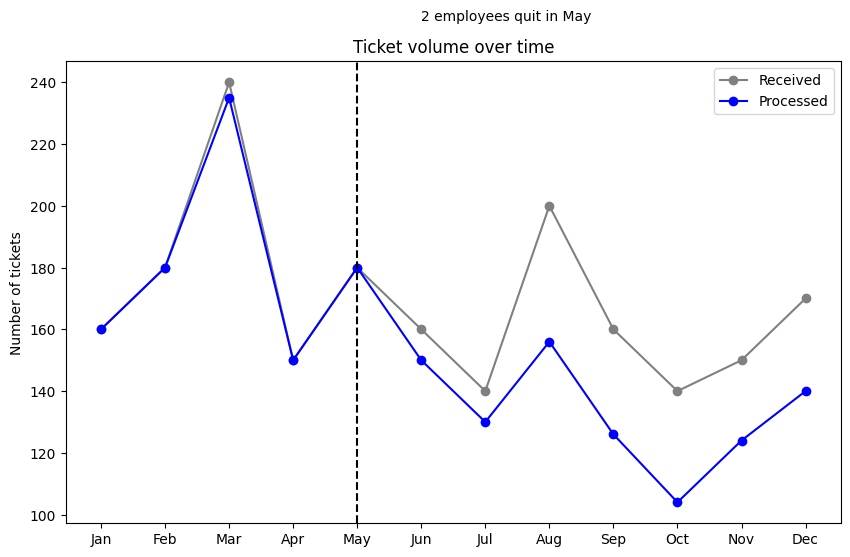

In [11]:
import matplotlib.pyplot as plt

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

received = [160, 180, 240, 150, 180, 160, 140, 200, 160, 140, 150, 170]
processed = [160, 180, 235, 150, 180, 150, 130, 156, 126, 104, 124, 140]

plt.figure(figsize=(10,6))

plt.plot(months, received, marker='o', color='gray', label='Received')
plt.plot(months, processed, marker='o', color='blue', label='Processed')

# Simple annotation
plt.axvline(x="May", color='black', linestyle='--')
plt.text(5, 260, "2 employees quit in May", fontsize=10)

plt.title("Ticket volume over time")
plt.ylabel("Number of tickets")

plt.legend()
plt.show()

Figure 5.10